In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

In [3]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.1307,), (0.3081,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training data volume: {len(train_dataset)}")
print(f"The size of the verification data : {len(val_dataset)}")
print(f"Test data volume : {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 615kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]

Training data volume: 48000
The size of the verification data : 12000
Test data volume : 10000


In [4]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[128, 64], num_classes=10,
                 activation_fn='relu', use_dropout=False, use_batchnorm=False, dropout_prob=0.3):
        super(MLP, self).__init__()


        if activation_fn == 'relu':
            self.activation = nn.ReLU()
        elif activation_fn == 'tanh':
            self.activation = nn.Tanh()
        elif activation_fn == 'sigmoid':
            self.activation = nn.Sigmoid()

        layers = []
        prev_size = input_size

        # Hidden Layers
        for i, hidden_size in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, hidden_size))

            # Batch Normalization
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))

            layers.append(self.activation)

            # Dropout
            if use_dropout:
                layers.append(nn.Dropout(dropout_prob))

            prev_size = hidden_size

        # Output Layer
        layers.append(nn.Linear(prev_size, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.network(x)

In [5]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def run_experiment(model, train_loader, val_loader, criterion, optimizer, epochs=15, experiment_name="Exp"):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"Start the experiment: {experiment_name} ")
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    return history

In [6]:
epochs = 15
criterion = nn.CrossEntropyLoss()

# The first experience (Baseline):
model_exp1 = MLP(hidden_sizes=[128, 64], activation_fn='relu', use_dropout=False, use_batchnorm=False).to(device)
optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=0.001)
history_exp1 = run_experiment(model_exp1, train_loader, val_loader, criterion, optimizer_exp1, epochs, "Experiment 1 (Baseline)")

# The second experiment (Enhanced):
model_exp2 = MLP(hidden_sizes=[512, 256], activation_fn='relu', use_dropout=True, use_batchnorm=True, dropout_prob=0.4).to(device)
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=0.0005)
history_exp2 = run_experiment(model_exp2, train_loader, val_loader, criterion, optimizer_exp2, epochs, "Experiment 2 (Enhanced)")


Start the experiment: Experiment 1 (Baseline) 
Epoch [1/15] - Train Loss: 0.2974, Val Loss: 0.1612 | Train Acc: 91.33%, Val Acc: 94.99%
Epoch [2/15] - Train Loss: 0.1273, Val Loss: 0.1258 | Train Acc: 96.15%, Val Acc: 96.24%
Epoch [3/15] - Train Loss: 0.0876, Val Loss: 0.1194 | Train Acc: 97.28%, Val Acc: 96.25%
Epoch [4/15] - Train Loss: 0.0645, Val Loss: 0.0961 | Train Acc: 97.94%, Val Acc: 97.15%
Epoch [5/15] - Train Loss: 0.0521, Val Loss: 0.1018 | Train Acc: 98.36%, Val Acc: 96.93%
Epoch [6/15] - Train Loss: 0.0422, Val Loss: 0.0880 | Train Acc: 98.58%, Val Acc: 97.14%
Epoch [7/15] - Train Loss: 0.0325, Val Loss: 0.0958 | Train Acc: 98.90%, Val Acc: 97.21%
Epoch [8/15] - Train Loss: 0.0288, Val Loss: 0.0967 | Train Acc: 99.05%, Val Acc: 97.39%
Epoch [9/15] - Train Loss: 0.0279, Val Loss: 0.1045 | Train Acc: 99.04%, Val Acc: 97.27%
Epoch [10/15] - Train Loss: 0.0198, Val Loss: 0.1031 | Train Acc: 99.30%, Val Acc: 97.47%
Epoch [11/15] - Train Loss: 0.0201, Val Loss: 0.1054 | Train A

In [7]:
test_loss_exp1, test_acc_exp1 = evaluate(model_exp1, test_loader, criterion, device)
test_loss_exp2, test_acc_exp2 = evaluate(model_exp2, test_loader, criterion, device)

print(f"Experiment 1 Accuracy: {test_acc_exp1:.2f}% | Final Loss: {test_loss_exp1:.4f}")
print(f"Experiment 2 Accuracy: {test_acc_exp2:.2f}% | Final Loss: {test_loss_exp2:.4f}")

Experiment 1 Accuracy: 97.50% | Final Loss: 0.1107
Experiment 2 Accuracy: 98.16% | Final Loss: 0.0557


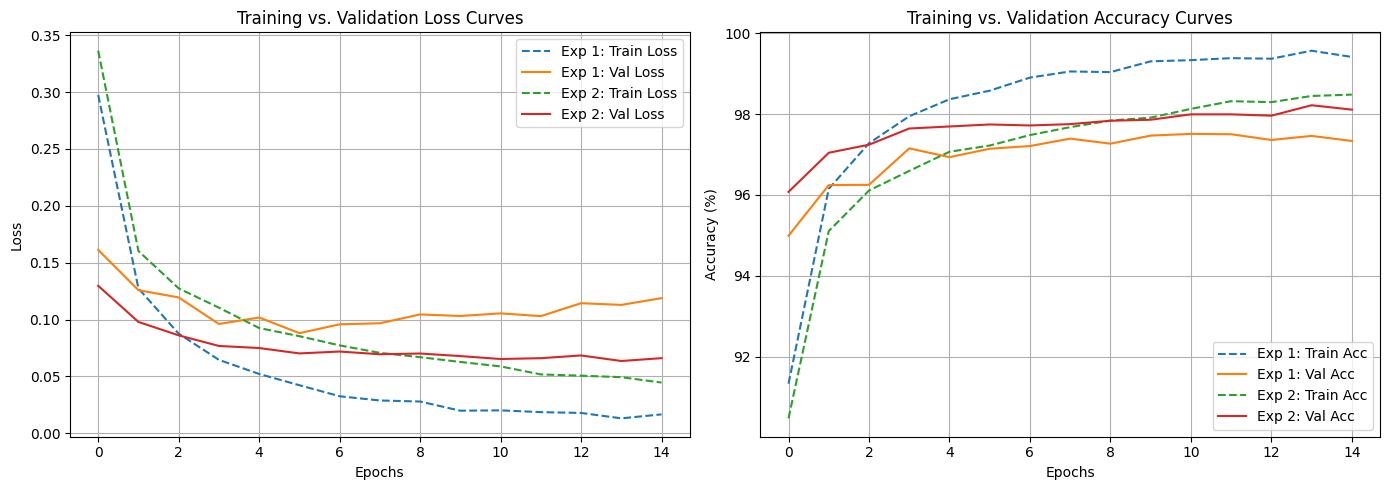

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
ax1.plot(history_exp1['train_loss'], label='Exp 1: Train Loss', linestyle='--')
ax1.plot(history_exp1['val_loss'], label='Exp 1: Val Loss')
ax1.plot(history_exp2['train_loss'], label='Exp 2: Train Loss', linestyle='--')
ax1.plot(history_exp2['val_loss'], label='Exp 2: Val Loss')
ax1.set_title('Training vs. Validation Loss Curves')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy Curves
ax2.plot(history_exp1['train_acc'], label='Exp 1: Train Acc', linestyle='--')
ax2.plot(history_exp1['val_acc'], label='Exp 1: Val Acc')
ax2.plot(history_exp2['train_acc'], label='Exp 2: Train Acc', linestyle='--')
ax2.plot(history_exp2['val_acc'], label='Exp 2: Val Acc')
ax2.set_title('Training vs. Validation Accuracy Curves')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()